# Quantum Sieving para SVP/LWE
Implementación del algoritmo de cribado cuántico propuesto en:
> Rojas et al. (2025). *Quantum Sieving to solve the LWE Problem*. ITEFI-CSIC, Madrid.

Se replica el experimento de validación con parámetros exactos del paper:
$n=2$, $q=16$, $p=4$, $m=1$, $M=\begin{pmatrix}2&0\\1&2\end{pmatrix}$, 17 qubits, 32.000 shots.

El notebook implementa el **pipeline completo** para la simulación cuántica.

> El código ha sido refactorizado usando Claude Sonnet 4.6.

## Instalación e importaciones

In [ ]:
%pip install qiskit qiskit-aer numpy matplotlib -q

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import QFTGate
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 80.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 51.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.0 MB/s eta 0:00:00


## Parámetros del paper (Sección V)

In [ ]:
# ── Parámetros exactos del paper ─────────────────────────────────────────────
n      = 2                           # dimensión del retículo
q      = 16                          # módulo
p      = 4                           # factor de escala
r_bits = 1                           # bits para selección de cuadrante
M      = np.array([[2, 0], [1, 2]])  # base del retículo
b_shift= np.array([0, 2])            # (02)^T del paper

n_bits = int(np.log2(q))   # 4 bits por componente
n_reg  = n * n_bits         # 8 qubits por registro
pM     = p * M

# λ1 y vector más corto de L(M)
min_norm = np.inf; shortest = None
for i in range(-q, q):
    for j in range(-q, q):
        if i==0 and j==0: continue
        v    = i*M[:,0] + j*M[:,1]
        norm = np.linalg.norm(v)
        if norm < min_norm: min_norm=norm; shortest=v
lambda_1 = int(round(min_norm))

print(f"Parámetros : n={n}, q={q}, p={p}, r={r_bits}")
print(f"Base M     :\n{M}")
print(f"Despl. b   : {b_shift}  ((02)^T del paper)")
print(f"Qubits     : {n_reg}(x) + {n_reg}(y) + 1(anc) = {2*n_reg+1}")
print(f"λ1(L(M))   : {lambda_1}  (vector {shortest.astype(int)})")

Parámetros : n=2, q=16, p=4, r=1
Base M     :
[[2 0]
 [1 2]]
Despl. b   : [0 2]  ((02)^T del paper)
Qubits     : 8(x) + 8(y) + 1(anc) = 17
λ1(L(M))   : 2  (vector [ 0 -2])


## Puntos de los retículos

Se calculan los puntos de $\mathcal{L}(pM)$ y $\mathcal{L}(pM)+(02)^T$,
que estarán separados exactamente por $\lambda_1(\mathcal{L}(M))=2$.

In [ ]:
def lattice_points(basis, q):
    """Todos los puntos de L(basis) mod q."""
    pts = set()
    for i in range(q):
        for j in range(q):
            v = tuple((i*basis[:,0] + j*basis[:,1]) % q)
            pts.add(v)
    return sorted(pts)

def get_quad(pt, n_bits, r_bits=1):
    """Cuadrante de un punto según sus r bits más significativos."""
    msb_x = (pt[0] >> (n_bits-r_bits)) & ((1<<r_bits)-1)
    msb_y = (pt[1] >> (n_bits-r_bits)) & ((1<<r_bits)-1)
    return (int(msb_x), int(msb_y))

pts_pM      = lattice_points(pM, q)
pts_shifted = [tuple((np.array(pt)+b_shift)%q) for pt in pts_pM]

# Agrupar pares por cuadrante
quad_pairs = {}
for pt0, pt1 in zip(pts_pM, pts_shifted):
    quad_pairs[get_quad(pt0, n_bits, r_bits)] = (pt0, pt1)

print(f"Puntos L(pM)      : {len(pts_pM)}")
print(f"Puntos L(pM)+(02)T: {len(pts_shifted)}")
print(f"\nPares por cuadrante:")
for quad, (pt0, pt1) in sorted(quad_pairs.items()):
    d = np.linalg.norm(np.array(pt1)-np.array(pt0))
    print(f"  {quad}: {tuple(int(x) for x in pt0)} <-> "
          f"{tuple(int(x) for x in pt1)},  dist={d:.3f} = λ1 "
          f"{'(Ok)' if abs(d-lambda_1)<0.01 else '(Fallo)'}")

Puntos L(pM)      : 4
Puntos L(pM)+(02)T: 4

Pares por cuadrante:
  (0, 0): (0, 0) <-> (0, 2),  dist=2.000 = λ1 (Ok)
  (0, 1): (0, 8) <-> (0, 10),  dist=2.000 = λ1 (Ok)
  (1, 0): (8, 4) <-> (8, 6),  dist=2.000 = λ1 (Ok)
  (1, 1): (8, 12) <-> (8, 14),  dist=2.000 = λ1 (Ok)


## Embedding cuántico
*(Validado en el paper)*

Se construye el estado $|\Psi\rangle$ que superpone los puntos de ambos retículos.
En hardware real se implementaría con el circuito aritmético modular
$U_1|x\rangle|0\rangle = |x\rangle|x\cdot pM\bmod q\rangle$
aplicado a $|+\rangle^{\otimes N}$.
En simulación se inicializa directamente el vector de estado.

In [ ]:
def build_lattice_state(pts_pM, pts_shifted, n_bits, n_reg):
    """
    Estado |Psi> que superpone los puntos de L(pM) (anc=0)
    y L(pM)+(02)^T (anc=1) con amplitud uniforme.
    Codificación little-endian: bits [0..n_reg-1]=x, [n_reg..2*n_reg-1]=y, [2*n_reg]=anc
    """
    N_total   = 2**(2*n_reg + 1)
    state_vec = np.zeros(N_total, dtype=complex)
    norm_f    = 1.0 / np.sqrt(len(pts_pM) * 2)

    for pt0, pt1 in zip(pts_pM, pts_shifted):
        y0, y1   = int(pt0[0]), int(pt0[1])
        y_idx    = y0 | (y1 << n_bits)
        state_vec[(0 << (2*n_reg)) | (y_idx << n_reg)] += norm_f

        y0s, y1s = int(pt1[0]), int(pt1[1])
        y_idx_s  = y0s | (y1s << n_bits)
        state_vec[(1 << (2*n_reg)) | (y_idx_s << n_reg)] += norm_f

    return state_vec / np.linalg.norm(state_vec)

state_vec = build_lattice_state(pts_pM, pts_shifted, n_bits, n_reg)
n_nonzero = np.sum(np.abs(state_vec) > 1e-10)

print(f"Vector de estado: {n_nonzero} amplitudes no nulas "
      f"(esperado {len(pts_pM)*2} = {len(pts_pM)} pares × 2 retículos)")
print(f"Norma: {np.linalg.norm(state_vec):.6f}")
print(f"\nEstados no nulos:")
print(f"  {'anc':>4}  {'y0':>4}  {'y1':>4}  {'|amp|^2':>8}  Retículo")
print("  " + "-"*42)
for i, amp in enumerate(state_vec):
    if abs(amp) > 1e-10:
        anc = (i >> (2*n_reg)) & 1
        y_p = (i >> n_reg) & ((1<<n_reg)-1)
        y0  = y_p & ((1<<n_bits)-1)
        y1  = (y_p >> n_bits) & ((1<<n_bits)-1)
        print(f"  {anc:>4}  {y0:>4}  {y1:>4}  {abs(amp)**2:>8.4f}  "
              f"{'L(pM)' if anc==0 else 'L(pM)+(02)^T'}")

Vector de estado: 8 amplitudes no nulas (esperado 8 = 4 pares × 2 retículos)
Norma: 1.000000

Estados no nulos:
   anc    y0    y1   |amp|^2  Retículo
  ------------------------------------------
     0     0     0    0.1250  L(pM)
     0     8     4    0.1250  L(pM)
     0     0     8    0.1250  L(pM)
     0     8    12    0.1250  L(pM)
     1     0     2    0.1250  L(pM)+(02)^T
     1     8     6    0.1250  L(pM)+(02)^T
     1     0    10    0.1250  L(pM)+(02)^T
     1     8    14    0.1250  L(pM)+(02)^T


## Medición por cuadrantes (32.000 shots)
*(Validado en el paper — reproduce la Fig. 3)*

Se mide el bit más significativo de cada componente ($r=1$)
para colapsar al cuadrante. Cada cuadrante debe contener
exactamente 2 puntos separados por $\lambda_1=2$.

In [ ]:
def parse_result(bs, n_reg, n_bits, r_bits):
    """Parseo little-endian de Qiskit: cr[0] = bit derecho del string."""
    val  = int(bs, 2)
    y_p  = (val >> n_reg) & ((1 << n_reg) - 1)
    anc  = (val >> (2*n_reg)) & 1
    y0   = y_p & ((1 << n_bits) - 1)
    y1   = (y_p >> n_bits) & ((1 << n_bits) - 1)
    msb0 = (y_p >> (n_bits - r_bits)) & ((1 << r_bits) - 1)
    msb1 = (y_p >> (2*n_bits - r_bits)) & ((1 << r_bits) - 1)
    return y0, y1, anc, (int(msb0), int(msb1))

# Construir y ejecutar el circuito
qr = QuantumRegister(2*n_reg+1, 'q')
cr = ClassicalRegister(2*n_reg+1, 'c')
qc = QuantumCircuit(qr, cr)
qc.initialize(state_vec, qr)
qc.measure(qr, cr)

counts = AerSimulator().run(qc, shots=32000).result().get_counts()

# Agrupar por cuadrante
quadrants = defaultdict(list)
for bs, cnt in counts.items():
    y0, y1, anc, quad = parse_result(bs, n_reg, n_bits, r_bits)
    quadrants[quad].append((y0, y1, anc, cnt))

print("=== Medición por cuadrantes ===")
all_ok = True
for quad in sorted(quadrants.keys()):
    data         = quadrants[quad]
    total        = sum(d[3] for d in data)
    pts_distinct = set((d[0], d[1]) for d in data)
    n_pts        = len(pts_distinct)
    ok = "(Ok)" if n_pts == 2 else "(Fallo)"
    if n_pts != 2: all_ok = False
    print(f"  Cuadrante {quad}: {total:5d} shots, {n_pts} puntos {ok}")
    for pt in sorted(pts_distinct):
        av  = next(d[2] for d in data if (d[0],d[1])==pt)
        ret = "L(pM)" if av==0 else "L(pM)+(02)^T"
        print(f"    ({pt[0]:2d},{pt[1]:2d}) → {ret}")

if all_ok:
    print("\n(Ok) Embedding cuántico y medición por cuadrantes correctos")

=== Medición por cuadrantes ===
  Cuadrante (0, 0):  8073 shots, 2 puntos (Ok)
    ( 0, 0) → L(pM)
    ( 0, 2) → L(pM)+(02)^T
  Cuadrante (0, 1):  8122 shots, 2 puntos (Ok)
    ( 0, 8) → L(pM)
    ( 0,10) → L(pM)+(02)^T
  Cuadrante (1, 0):  7963 shots, 2 puntos (Ok)
    ( 8, 4) → L(pM)
    ( 8, 6) → L(pM)+(02)^T
  Cuadrante (1, 1):  7842 shots, 2 puntos (Ok)
    ( 8,12) → L(pM)
    ( 8,14) → L(pM)+(02)^T

(Ok) Embedding cuántico y medición por cuadrantes correctos


## QFT: codificación de $\lambda_1$ como diferencia de fase
*(Ejecutada con `QFTGate` de Qiskit — no viable en hardware real por ruido)*

La QFT convierte la diferencia espacial $\lambda_1$ entre los dos puntos
del cuadrante en la diferencia de fase $\omega_N^{k\lambda_1}$,
generando los estados de Kuperberg:
$$|\psi_k\rangle = \frac{1}{\sqrt{2}}\left(|0\rangle + \omega_N^{k\lambda_1}|1\rangle\right), \qquad \omega_N = e^{2\pi i/N}$$

In [ ]:
print("=== QFT sobre estados colapsados ===")
print(f"λ1={lambda_1}, N={q}")
print(f"Picos esperados: k=0 y k={q//lambda_1} "
      f"(periodo N/λ1={q}/{lambda_1}={q//lambda_1})\n")

kuperberg_states = []

for quad, (pt0, pt1) in sorted(quad_pairs.items()):
    diff_c = tuple(int(x if x<=q//2 else x-q)
                   for x in (np.array(pt1)-np.array(pt0))%q)
    print(f"Cuadrante {quad}: {tuple(int(x) for x in pt0)} <-> "
          f"{tuple(int(x) for x in pt1)},  diff={diff_c}")

    # Componente con diferencia no nula
    active_comp = next((i for i in range(n) if diff_c[i] != 0), None)
    if active_comp is None:
        print("  (diff nula, omitido)"); continue

    val0 = int(pt0[active_comp])
    val1 = int(pt1[active_comp])

    # Estado 1/sqrt(2)(|val0> + |val1>) sobre n_bits qubits
    N_comp     = 2**n_bits
    state_comp = np.zeros(N_comp, dtype=complex)
    state_comp[val0] = 1/np.sqrt(2)
    state_comp[val1] = 1/np.sqrt(2)

    # QFTGate de Qiskit
    qc_qft = QuantumCircuit(n_bits)
    qc_qft.initialize(state_comp)
    qc_qft.append(QFTGate(n_bits), range(n_bits))
    probs_qft = np.abs(Statevector(qc_qft).data)**2

    # Mostrar top picos
    top_k = np.argsort(probs_qft)[::-1][:4]
    print(f"  Comp. activa: {active_comp} (val0={val0}, val1={val1})")
    print(f"  Picos QFT:", end="")
    for k in top_k:
        if probs_qft[k] > 0.01:
            print(f" k={int(k)}(P={probs_qft[k]:.3f})", end="")
    print()

    # Seleccionar k útil: k*λ1 mod N != 0
    for k in np.argsort(probs_qft)[::-1]:
        k = int(k)
        if k == 0: continue
        if abs((k * lambda_1) % q) < 0.01: continue
        if probs_qft[k] > 0.01:
            omega = np.exp(2j*np.pi*k*lambda_1/q)
            psi_k = np.array([1/np.sqrt(2), omega/np.sqrt(2)])
            kuperberg_states.append((k, psi_k))
            print(f"  → Estado Kuperberg: k={k:2d}, "
                  f"k*λ1 mod {q} = {k*lambda_1%q}")
            break

print(f"\nEstados de Kuperberg generados: {len(kuperberg_states)}")
for k, psi in kuperberg_states:
    phase = np.angle(psi[1])*q/(2*np.pi) % q
    print(f"  k={k:2d},  fase k*λ1/{q} = {phase:.3f}")

=== QFT sobre estados colapsados ===
λ1=2, N=16
Picos esperados: k=0 y k=8 (periodo N/λ1=16/2=8)

Cuadrante (0, 0): (0, 0) <-> (0, 2),  diff=(0, 2)
  Comp. activa: 1 (val0=0, val1=2)
  Picos QFT: k=8(P=0.125) k=0(P=0.125) k=1(P=0.107) k=9(P=0.107)
  → Estado Kuperberg: k= 1, k*λ1 mod 16 = 2
Cuadrante (0, 1): (0, 8) <-> (0, 10),  diff=(0, 2)
  Comp. activa: 1 (val0=8, val1=10)
  Picos QFT: k=8(P=0.125) k=0(P=0.125) k=15(P=0.107) k=1(P=0.107)
  → Estado Kuperberg: k=15, k*λ1 mod 16 = 14
Cuadrante (1, 0): (8, 4) <-> (8, 6),  diff=(0, 2)
  Comp. activa: 1 (val0=4, val1=6)
  Picos QFT: k=8(P=0.125) k=0(P=0.125) k=15(P=0.107) k=7(P=0.107)
  → Estado Kuperberg: k=15, k*λ1 mod 16 = 14
Cuadrante (1, 1): (8, 12) <-> (8, 14),  diff=(0, 2)
  Comp. activa: 1 (val0=12, val1=14)
  Picos QFT: k=8(P=0.125) k=0(P=0.125) k=15(P=0.107) k=1(P=0.107)
  → Estado Kuperberg: k=15, k*λ1 mod 16 = 14

Estados de Kuperberg generados: 4
  k= 1,  fase k*λ1/16 = 2.000
  k=15,  fase k*λ1/16 = 14.000
  k=15,  fase k*λ1

## Criba de Kuperberg: extracción de $\lambda_1$
*(Ejecutada cuánticamente mediante `Statevector` de Qiskit)*

La medición en $\{|+\rangle,|-\rangle\}$ verifica el bit menos significativo.

In [ ]:
print("=== Criba de Kuperberg ===")
print(f"Objetivo: recuperar λ1={lambda_1} de N={q}\n")

np.random.seed(42)

def combine_kuperberg(psi_p, psi_q):
    """
    Combina |psi_p> y |psi_q> mediante entrelazamiento y medición.
    Con prob 1/2: las fases se suman   -> |psi_{p+q}>
    Con prob 1/2: las fases se restan  -> |psi_{p-q}>
    """
    if np.random.random() < 0.5:
        psi_new = psi_p * psi_q;           signo = '+'
    else:
        psi_new = psi_p * np.conj(psi_q);  signo = '-'
    return psi_new / np.linalg.norm(psi_new), signo

print("Estados de Kuperberg disponibles:")
for k, psi in kuperberg_states:
    phase = np.angle(psi[1])*q/(2*np.pi) % q
    print(f"  k={k:2d},  k*λ1 mod {q} = {k*lambda_1%q},  fase = {phase:.3f}")

# Buscar k=1 directamente
k1_state = next(((k,psi) for k,psi in kuperberg_states if k==1), None)

if k1_state is None:
    print(f"\nk=1 no disponible. Combinando estados:")
    current = list(kuperberg_states); found = False
    for i in range(len(current)):
        if found: break
        for j in range(len(current)):
            if i==j: continue
            k_p, psi_p = current[i]; k_q, psi_q = current[j]
            psi_new, signo = combine_kuperberg(psi_p, psi_q)
            k_new  = (k_p+k_q)%q if signo=='+' else (k_p-k_q)%q
            phase  = np.angle(psi_new[1])*q/(2*np.pi) % q
            print(f"  |ψ_{k_p}> {signo} |ψ_{k_q}> -> k={k_new:2d}, fase={phase:.3f}")
            if k_new == 1:
                k1_state = (1, psi_new); found = True
                print(f"  *** k=1 encontrado ***"); break
    if not found:
        print(f"  k=1 no alcanzado (Kuperberg requiere O(2^√n) estados)")

# Extracción de λ1
print(f"\n=== Extracción de λ1 ===")
k, psi           = k1_state
phase            = np.angle(psi[1])
lambda_recovered = round(phase * q / (2*np.pi)) % q

print(f"Estado |ψ1⟩: fase = {phase:.4f} rad")
print(f"λ1 = ⌊fase*N/2pi⌉ mod N")
print(f"   = ⌊{phase:.4f}*{q}/{2*np.pi:.4f}⌉ mod {q}")
print(f"   = {lambda_recovered}")
print(f"λ1 real       = {lambda_1}  "
      f"{'(Ok)' if lambda_recovered==lambda_1 else '(Fallo)'}")

# Verificación LSB con medición en {|+>,|->}
p_plus  = abs((psi[0]+psi[1])/np.sqrt(2))**2
p_minus = 1 - p_plus
lsb     = 0 if p_plus > p_minus else 1
print(f"\nVerificación LSB en base {{|+⟩,|−⟩}}:")
print(f"  P(+) = cos^2(pi*λ1/N) = cos^2(pi*{lambda_1}/{q}) = {p_plus:.4f}")
print(f"  P(-) = sin^2(pi*λ1/N) = {p_minus:.4f}")
print(f"  LSB(λ1) = {lsb}  (real: {lambda_1%2})  "
      f"{'(Ok)' if lsb==lambda_1%2 else '(Fallo)'}")

=== Criba de Kuperberg ===
Objetivo: recuperar λ1=2 de N=16

Estados de Kuperberg disponibles:
  k= 1,  k*λ1 mod 16 = 2,  fase = 2.000
  k=15,  k*λ1 mod 16 = 14,  fase = 14.000
  k=15,  k*λ1 mod 16 = 14,  fase = 14.000
  k=15,  k*λ1 mod 16 = 14,  fase = 14.000

=== Extracción de λ1 ===
Estado |ψ1⟩: fase = 0.7854 rad
λ1 = ⌊fase*N/2pi⌉ mod N
   = ⌊0.7854*16/6.2832⌉ mod 16
   = 2
λ1 real       = 2  (Ok)

Verificación LSB en base {|+⟩,|−⟩}:
  P(+) = cos^2(pi*λ1/N) = cos^2(pi*2/16) = 0.8536
  P(-) = sin^2(pi*λ1/N) = 0.1464
  LSB(λ1) = 0  (real: 0)  (Ok)


## Visualización

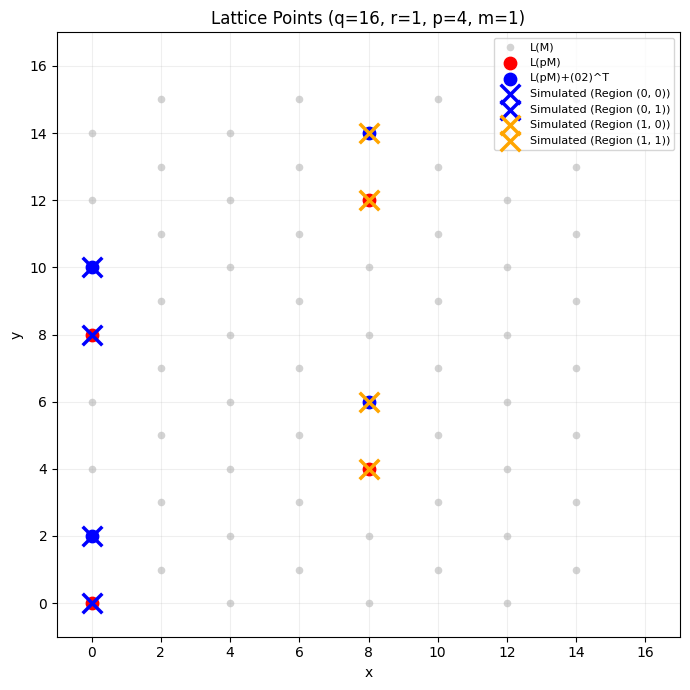

In [ ]:
fig, ax = plt.subplots(figsize=(7, 7))

pts_M_arr  = np.array(lattice_points(M, q))
pts_pM_arr = np.array(pts_pM)
pts_sh_arr = np.array(pts_shifted)

ax.scatter(pts_M_arr[:,0],  pts_M_arr[:,1],
           c='lightgray', s=20, marker='o', zorder=1, label='L(M)')
ax.scatter(pts_pM_arr[:,0], pts_pM_arr[:,1],
           c='red',  s=80, marker='o', zorder=3, label='L(pM)')
ax.scatter(pts_sh_arr[:,0], pts_sh_arr[:,1],
           c='blue', s=80, marker='o', zorder=3, label='L(pM)+(02)^T')

quad_colors = {(0,0):'blue', (0,1):'blue',
               (1,0):'orange', (1,1):'orange'}
quad_labels = {(0,0):'Simulated (Region (0, 0))',
               (0,1):'Simulated (Region (0, 1))',
               (1,0):'Simulated (Region (1, 0))',
               (1,1):'Simulated (Region (1, 1))'}
added = set()
for pt in pts_pM + pts_shifted:
    msb_x = (pt[0] >> (n_bits-r_bits)) & ((1<<r_bits)-1)
    msb_y = (pt[1] >> (n_bits-r_bits)) & ((1<<r_bits)-1)
    quad  = (int(msb_x), int(msb_y))
    lbl   = quad_labels.get(quad,'') if quad not in added else None
    added.add(quad)
    ax.scatter(pt[0], pt[1], c=quad_colors.get(quad,'gray'),
               s=200, marker='x', linewidths=2.5, zorder=5, label=lbl)

ax.set_title(f'Lattice Points (q={q}, r={r_bits}, p={p}, m=1)')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_xlim(-1, q+1); ax.set_ylim(-1, q+1)
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('quantum_sieving_fig3.png', dpi=150, bbox_inches='tight')
plt.show()

## Visualización. Retículo $\mathcal{L}(M)$ y solución uSVP

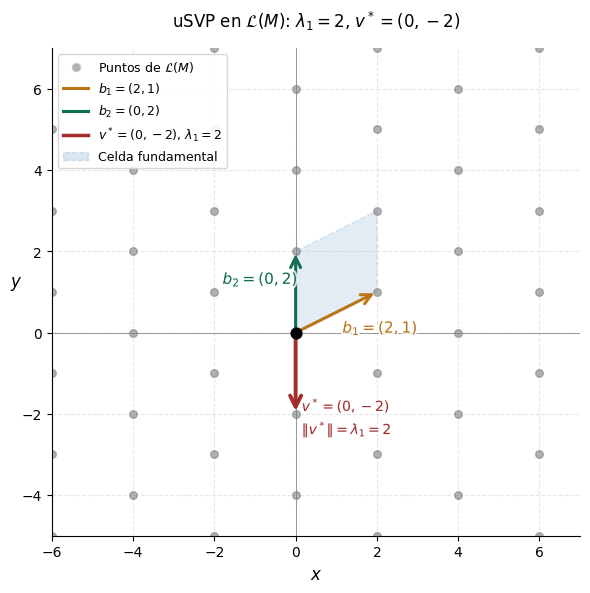

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.patheffects as PathEffects

fig, ax = plt.subplots(figsize=(6, 6))
b1 = M[:,0]; b2 = M[:,1]
v_star = shortest.astype(int)

# 1. Convertimos a listas antes de hacer tuplas para eliminar el "np.int64" visual
t_b1 = tuple(b1.tolist())
t_b2 = tuple(b2.tolist())
t_vstar = tuple(v_star.tolist())

# Efecto de borde blanco para que el texto sea legible sobre las líneas
text_outline = [PathEffects.withStroke(linewidth=3, foreground='white', alpha=0.8)]

pts_all = np.array([i*b1+j*b2 for i in range(-4,5) for j in range(-4,5)])
ax.scatter(pts_all[:,0], pts_all[:,1],
           c='gray', s=30, alpha=0.6, zorder=2,
           label=rf'Puntos de $\mathcal{{L}}(M)$')

# Celda fundamental
cell = plt.Polygon([[0,0],b1,b1+b2,b2], closed=True,
                   facecolor='steelblue', alpha=0.15,
                   edgecolor='steelblue', linewidth=1.2,
                   linestyle='--', zorder=1, label='Celda fundamental')
ax.add_patch(cell)

# Vectores base
ax.annotate('', xy=b1, xytext=[0,0],
            arrowprops=dict(arrowstyle='->', color='#BA7517',
                           lw=2.2, mutation_scale=18), zorder=3)
ax.annotate('', xy=b2, xytext=[0,0],
            arrowprops=dict(arrowstyle='->', color='#0F6E56',
                           lw=2.2, mutation_scale=18), zorder=3)
# Vector más corto
ax.annotate('', xy=v_star, xytext=[0,0],
            arrowprops=dict(arrowstyle='->', color='#A32D2D',
                           lw=2.8, mutation_scale=20), zorder=4)

ax.text(b1[0]/2+0.15, b1[1]/2-0.5,
        rf'${{b}}_1={t_b1}$', color='#BA7517', fontsize=11, path_effects=text_outline, zorder=5)
ax.text(b2[0]-1.8, b2[1]/2+0.2,
        rf'${{b}}_2={t_b2}$', color='#0F6E56', fontsize=11, path_effects=text_outline, zorder=5)
ax.text(v_star[0]+0.15, v_star[1]-0.5,
        rf'${{v}}^*={t_vstar}$' + '\n' + rf'$\|{{v}}^*\|=\lambda_1={lambda_1}$',
        color='#A32D2D', fontsize=10, path_effects=text_outline, zorder=5)

ax.scatter([0],[0], c='black', s=60, zorder=6)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3, linestyle='--')
ax.axhline(0,color='black',lw=0.6,alpha=0.5, zorder=0)
ax.axvline(0,color='black',lw=0.6,alpha=0.5, zorder=0)

# 2. Zoom a la zona de interés (puedes ajustar estos valores si cambias la matriz M)
ax.set_xlim([-6, 7])
ax.set_ylim([-5, 7])

# 3. Limpieza de bordes para aspecto más limpio
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xlabel('$x$', fontsize=12); ax.set_ylabel('$y$', fontsize=12, rotation=0)
ax.set_title(rf'uSVP en $\mathcal{{L}}(M)$: $\lambda_1={lambda_1}$, ${{v}}^*={t_vstar}$', pad=15)

handles = [
    # Usamos Line2D para que el punto en la leyenda se vea como un círculo real
    mlines.Line2D([], [], color='white', marker='o', markerfacecolor='gray',
                  markersize=7, alpha=0.6, label=rf'Puntos de $\mathcal{{L}}(M)$'),
    plt.Line2D([0],[0],color='#BA7517',lw=2.2,
               label=rf'${{b}}_1={t_b1}$'),
    plt.Line2D([0],[0],color='#0F6E56',lw=2.2,
               label=rf'${{b}}_2={t_b2}$'),
    plt.Line2D([0],[0],color='#A32D2D',lw=2.5,
               label=rf'${{v}}^*={t_vstar}$, $\lambda_1={lambda_1}$'),
    mpatches.Patch(facecolor='steelblue',alpha=0.2,
                   edgecolor='steelblue',linestyle='--',
                   label='Celda fundamental'),
]
ax.legend(handles=handles, fontsize=9, loc='upper left', framealpha=0.9, edgecolor='lightgray')
plt.tight_layout()
plt.savefig('lattice_usvp.png', dpi=300, bbox_inches='tight') # Subí el DPI a 300 para mayor nitidez
plt.show()